In [28]:
# Nombre: Yupari figueroa Rosa Isela
# dataset= House_Price:india_dataset
# link dataset: https://www.kaggle.com/datasets/hemachandiranmurugan/house-price-india-dataset
# n=23
# m=14619
# predicir el precio de la casa

In [1]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

In [2]:
#Carga de dataset
data = pd.read_csv('/content/House Price India.csv')

In [3]:
print(data)

               id   Date  number of bedrooms  number of bathrooms  \
0      6762810145  42491                   5                 2.50   
1      6762810635  42491                   4                 2.50   
2      6762810998  42491                   5                 2.75   
3      6762812605  42491                   4                 2.50   
4      6762812919  42491                   3                 2.00   
...           ...    ...                 ...                  ...   
14615  6762830250  42734                   2                 1.50   
14616  6762830339  42734                   3                 2.00   
14617  6762830618  42734                   2                 1.00   
14618  6762830709  42734                   4                 1.00   
14619  6762831463  42734                   3                 1.00   

       living area  lot area  number of floors  waterfront present  \
0             3650      9050               2.0                   0   
1             2920      4000   

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

In [8]:
# Lectura de Datos
X = data.iloc[:, :22]
y = data.iloc[:, 22]
m = y.size

In [9]:
print(X)
print('*'*25)
print(y)

               id   Date  number of bedrooms  number of bathrooms  \
0      6762810145  42491                   5                 2.50   
1      6762810635  42491                   4                 2.50   
2      6762810998  42491                   5                 2.75   
3      6762812605  42491                   4                 2.50   
4      6762812919  42491                   3                 2.00   
...           ...    ...                 ...                  ...   
14615  6762830250  42734                   2                 1.50   
14616  6762830339  42734                   3                 2.00   
14617  6762830618  42734                   2                 1.00   
14618  6762830709  42734                   4                 1.00   
14619  6762831463  42734                   3                 1.00   

       living area  lot area  number of floors  waterfront present  \
0             3650      9050               2.0                   0   
1             2920      4000   

In [10]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [11]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

               id   Date  number of bedrooms  number of bathrooms  \
0      6762810145  42491                   5                 2.50   
1      6762810635  42491                   4                 2.50   
2      6762810998  42491                   5                 2.75   
3      6762812605  42491                   4                 2.50   
4      6762812919  42491                   3                 2.00   
...           ...    ...                 ...                  ...   
14615  6762830250  42734                   2                 1.50   
14616  6762830339  42734                   3                 2.00   
14617  6762830618  42734                   2                 1.00   
14618  6762830709  42734                   4                 1.00   
14619  6762831463  42734                   3                 1.00   

       living area  lot area  number of floors  waterfront present  \
0             3650      9050               2.0                   0   
1             2920      4000   

In [12]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [13]:
print(X)

[[ 1.         -1.71314837 -1.68590818 ... -0.28220257 -0.01498123
  -0.77788599]
 [ 1.         -1.63458951 -1.68590818 ... -0.33592986 -0.01498123
  -1.56126035]
 [ 1.         -1.57639183 -1.68590818 ... -0.23615061 -1.23858786
  -1.33743911]
 ...
 [ 1.          1.56916901  1.92234067 ... -0.2545714  -0.01498123
  -0.10642226]
 [ 1.          1.58375852  1.92234067 ... -0.23496094  1.2086254
  -1.22552848]
 [ 1.          1.70464296  1.92234067 ... -0.35588571 -0.01498123
  -1.11361786]]


In [14]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0]

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [15]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0]

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [ 535309.99454865 -121500.20663112     680.6658504   -27871.96741515
   21160.40292578   66912.75361507   -3987.90787052   -4972.05979327
   47402.73982503   30204.28450085   13172.66921601   67516.66095323
   64184.93313108   19162.68174139  -46405.66990141    8298.95367874
   17813.20864293   34819.09318427  -17681.98876513    9476.01409518
   -9056.29661675    1411.34068144    -799.81181521]
El valor predecido ): 131598069604.0330


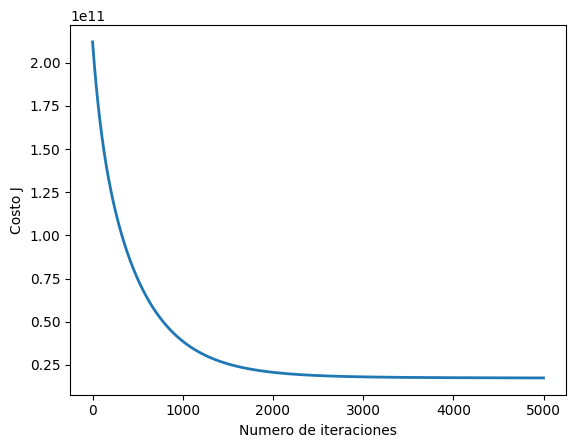

In [20]:
# Elegir algun valor para alpha
alpha = 0.001
num_iters = 5000

theta = np.zeros(23)
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Estimar el precio de una vivienda
X_array = [1, 2, 130, 32, 1, 17, 1.48, 29, 4, 12, 0, 1, 1, 2, 4, 2, 3, 2, 5, 4, 2, 5, 6]
X_array[1:23] = (X_array[1:23] - mu) / sigma
price = np.dot(X_array, theta)   # Se debe cambiar esto

print('El valor predecido ): {:.4f}'.format(price))

In [21]:
X_array = [1, 2, 130, 32, 1, 17, 1.48, 29, 4, 12, 0, 1, 1, 2, 4, 2, 3, 2, 5, 4, 2, 5, 6]
X_array[1:23] = (X_array[1:23] - mu) / sigma

In [23]:
X_array[1:23]

[-1084243.8519254364,
 -630.6942586390256,
 30.490104067410982,
 -1.4671655868954132,
 -2.242150829317503,
 -0.3980081225725409,
 50.900805658705124,
 45.78909157736104,
 15.356823679404691,
 -5.165425451883668,
 -5.687203052968197,
 -2.159779320618164,
 -0.6565337561178812,
 -66.69216385574956,
 -0.213655669722244,
 -6395.113834919578,
 -369.35597838725374,
 844.9129841804166,
 -2.8835038906056485,
 -0.4893596348502986,
 3.655838671599473,
 -6.597238379665714]

In [24]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [29]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# es el precio para una vivienda

X_array = [1, 2, 130, 32, 1, 17, 1.48, 29, 4, 12, 0, 1, 1, 2, 4, 2, 3, 2, 5, 4, 2, 5, 22450]
price = np.dot(X_array, theta)

print('Precio predecido para una cada de superficie): ${:.0f}'.format(price))

Theta calculado a partir de la ecuación de la normal: [ 538932.21832599 -137423.7323329    -1058.08811251    9808.92502322
  -74568.36529045 -235771.14947073    -830.99313056   37441.28909355
   51310.74127183   12104.92365394     895.47347687   92435.67167673
  332155.29924452  212871.85963802  -46649.63103181    4792.93506491
   20258.94661327   23915.39769387  -13976.45287136  -13465.49442607
   -9504.06411697    1332.20931144    -957.89966403]
Precio predecido para una cada de superficie): $-23066199
